# Descriptive Analysis

## General Conclusions
- **Finding 1: Life Sciences is the fastest growing sector nationally**
Consistent with path dependence and capability emergence — Life Sciences often grows from adjacent capabilities in chemistry, pharmaceuticals, and medical devices. However we should ask: is this growth happening in regions that already had related capabilities, or in greenfield locations? The scatter plot suggests it's mostly in the "emerging" quadrant (low LQ, high growth) — which under EEG means new capability formation, not deepening of existing specialisation.

- **Finding 2: Advanced Manufacturing declining across most regions**
Consistent with creative destruction and path dependence lock-in — regions heavily specialised in traditional manufacturing struggle to diversify. West Midlands and South Yorkshire are classic cases of industrial path dependence creating structural lock-in.

- **Finding 3: Business count declining across most regions and sectors**
Consistent with incumbent firm consolidation — EEG recognises that mature industrial systems can become dominated by large incumbents, reducing entrepreneurial dynamism. This is a systemic finding about the UK IS8 economy rather than a regional one.

## Candidates
- **Cardiff-Newport (2 LAD) - performing consistently across sectors**
Cardiff-Newport is the most theoretically puzzling of the three. It has:

Selective institutional thickness — Cardiff University, Welsh Government investment, and the Senedd create a strong public sector and knowledge economy foundation
Concentrated specialisation — Financial Services and Life Sciences both above LQ=1, but these sectors don't share obvious technological capabilities, which is atypical under EEG's related variety framework
Limited evidence of organic related variety — the co-presence of Financial Services and Life Sciences may reflect deliberate policy investment rather than spontaneous capability recombination

Under EEG this is an institutional rather than capability-driven performance story — the region's strength appears to come from policy decisions and anchor institution investment rather than the self-reinforcing industrial capability accumulation that EEG predicts. This raises the question of whether the performance is sustainable without continued policy support.
The Phase 2 question is precisely this theoretical puzzle: is Cardiff-Newport's frontier industry performance rooted in genuine capability development, or is it institutionally dependent? If the former, what are the hidden capability links between Financial Services and Life Sciences? If the latter, what would it take to build the related variety foundation that would make the performance self-sustaining?

- **West of England (3 LAD) - diversified frontier economy**
West of England is the most textbook EEG case of the three. It has:

Path dependence — long-established aerospace and defence anchors (Airbus in Filton, BAE Systems, Rolls-Royce) have created a deep manufacturing capability base that has accumulated over decades
Related variety — Advanced Manufacturing, Digital and Technologies, and Creative Industries co-locate and share capabilities. Aerospace engineering generates demand for precision digital systems; defence contracts stimulate R&D spillovers into adjacent sectors
Institutional thickness — University of Bristol, University of Bath, and UWE provide a strong knowledge base; GKN, Airbus and Rolls-Royce act as anchor institutions generating supply chain demand

Under EEG this is a capability deepening and diversification story — the region's existing industrial base is enabling recombination into new frontier sectors through related variety. It's the expected outcome when EEG conditions are met.
The Phase 2 question becomes less about why frontier industries haven't emerged and more about which sectors have unrealised expansion potential given the existing capability base, and whether the diversification process is self-sustaining or still dependent on a few large anchors.

- **Greater Manchester (10 LAD) — balanced but below national average**
Greater Manchester is the most theoretically straightforward of the three under EEG — but in a less exciting way. It has:

Institutional thickness — strong universities (Manchester, MMU, Salford), combined authority governance, strong R&D base
Some related variety — Creative Industries, Digital and Technologies, and Professional and Business Services are adjacent and co-located
But weak specialisation — most sectors below LQ=1, meaning despite having the conditions EEG predicts should drive frontier industry growth, the specialisation hasn't materialised

Under EEG this is a coordination failure — the ingredients are there but the system isn't producing the expected outcome. That's actually a compelling Phase 2 story: why hasn't Manchester's strong institutional base translated into frontier industry specialisation?


In [25]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml

# --- Setup ---
with open("../config.yml", "r") as f:
    config = yaml.safe_load(f)

# --- Load indicators panel ---
panel = pd.read_parquet("../processed_data/indicators_panel.parquet")

print(f"Shape: {panel.shape}")
print(f"Sectors: {sorted(panel['IS8_SECTOR'].unique())}")
print(f"Years: {panel['YEAR'].min()} — {panel['YEAR'].max()}")
print(f"LADs: {panel['GEOGRAPHY_CODE'].nunique()}")

Shape: (26950, 64)
Sectors: ['Advanced Manufacturing', 'Creative Industries', 'Defence', 'Digital and Technologies', 'Financial Services', 'Life Sciences', 'Professional and Business Services']
Years: 2015 — 2025
LADs: 350


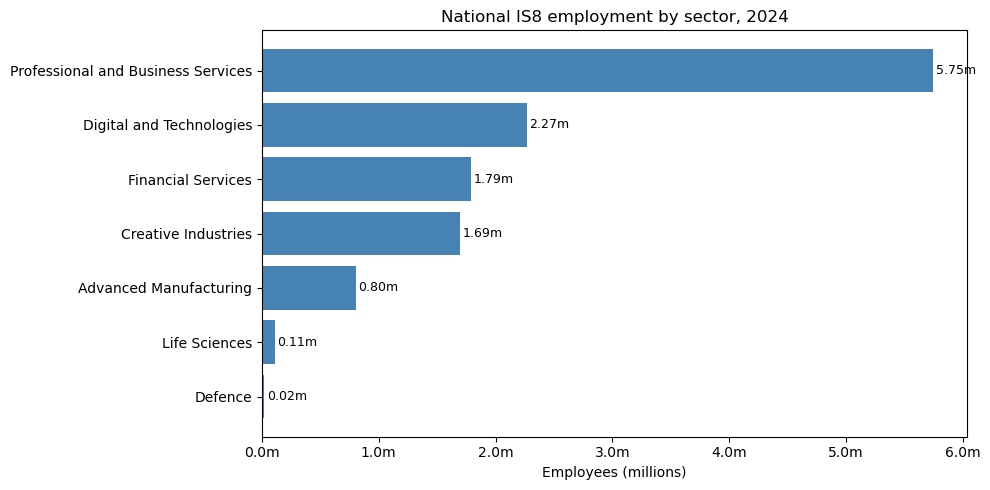

In [2]:
# --- National IS8 employment by sector (most recent year) ---
latest_year = 2024
national = (
    panel[panel['YEAR'] == latest_year]
    .groupby('IS8_SECTOR')['EMPLOYEES']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(national.index, national.values / 1_000_000, color='steelblue')
ax.set_xlabel('Employees (millions)')
ax.set_title(f'National IS8 employment by sector, {latest_year}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}m'))
for bar, val in zip(bars, national.values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val/1_000_000:.2f}m', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../output/charts/national_is8_employment_2024.png', dpi=150)
plt.show()

In [3]:
print(panel[panel['IS8_SECTOR'] == 'Defence']['EMPLOYEES'].describe())
print(f"\nDefence total 2024: {panel[(panel['IS8_SECTOR']=='Defence') & (panel['YEAR']==2024)]['EMPLOYEES'].sum():,}")
print(f"Non-zero LADs 2024: {(panel[(panel['IS8_SECTOR']=='Defence') & (panel['YEAR']==2024)]['EMPLOYEES'] > 0).sum()}")

count        3500.0
mean      49.664286
std      373.553677
min             0.0
25%             0.0
50%             0.0
75%             0.0
max          8000.0
Name: EMPLOYEES, dtype: Float64

Defence total 2024: 20,270
Non-zero LADs 2024: 51


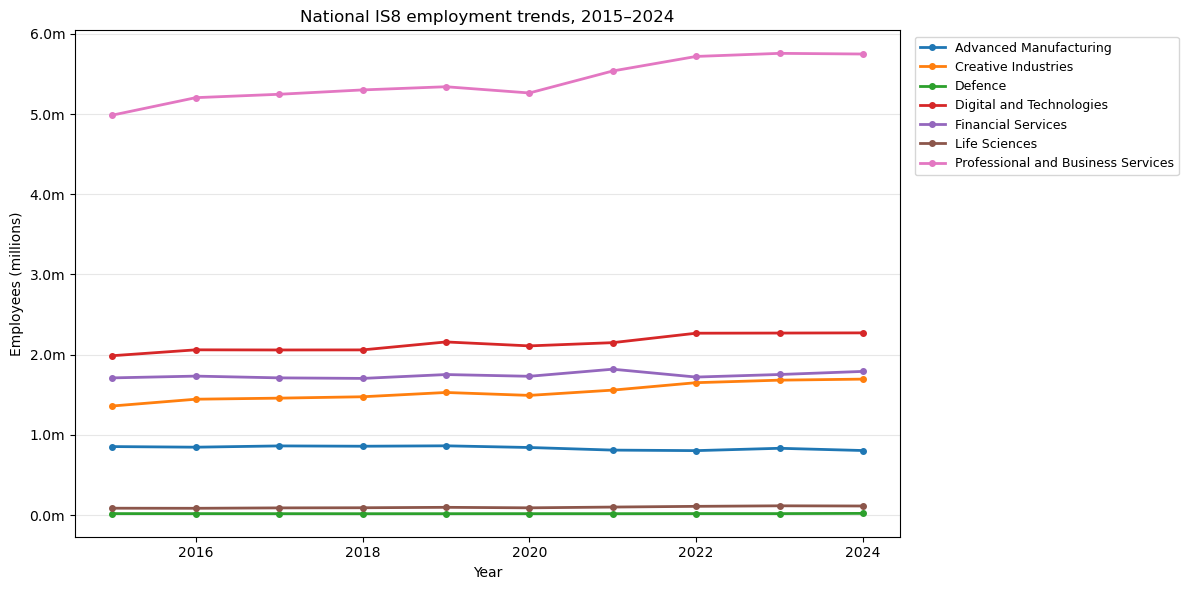

In [4]:
# --- National IS8 employment trends 2015–2024 ---
trends = (
    panel[panel['YEAR'] <= 2024]
    .groupby(['YEAR', 'IS8_SECTOR'])['EMPLOYEES']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

sectors = sorted(trends['IS8_SECTOR'].unique())
colors = plt.cm.tab10.colors

for i, sector in enumerate(sectors):
    data = trends[trends['IS8_SECTOR'] == sector].sort_values('YEAR')
    ax.plot(data['YEAR'], data['EMPLOYEES'] / 1_000_000,
            label=sector, color=colors[i], linewidth=2, marker='o', markersize=4)

ax.set_xlabel('Year')
ax.set_ylabel('Employees (millions)')
ax.set_title('National IS8 employment trends, 2015–2024')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}m'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../output/charts/national_is8_trends_2015_2024.png', dpi=150, bbox_inches='tight')
plt.show()

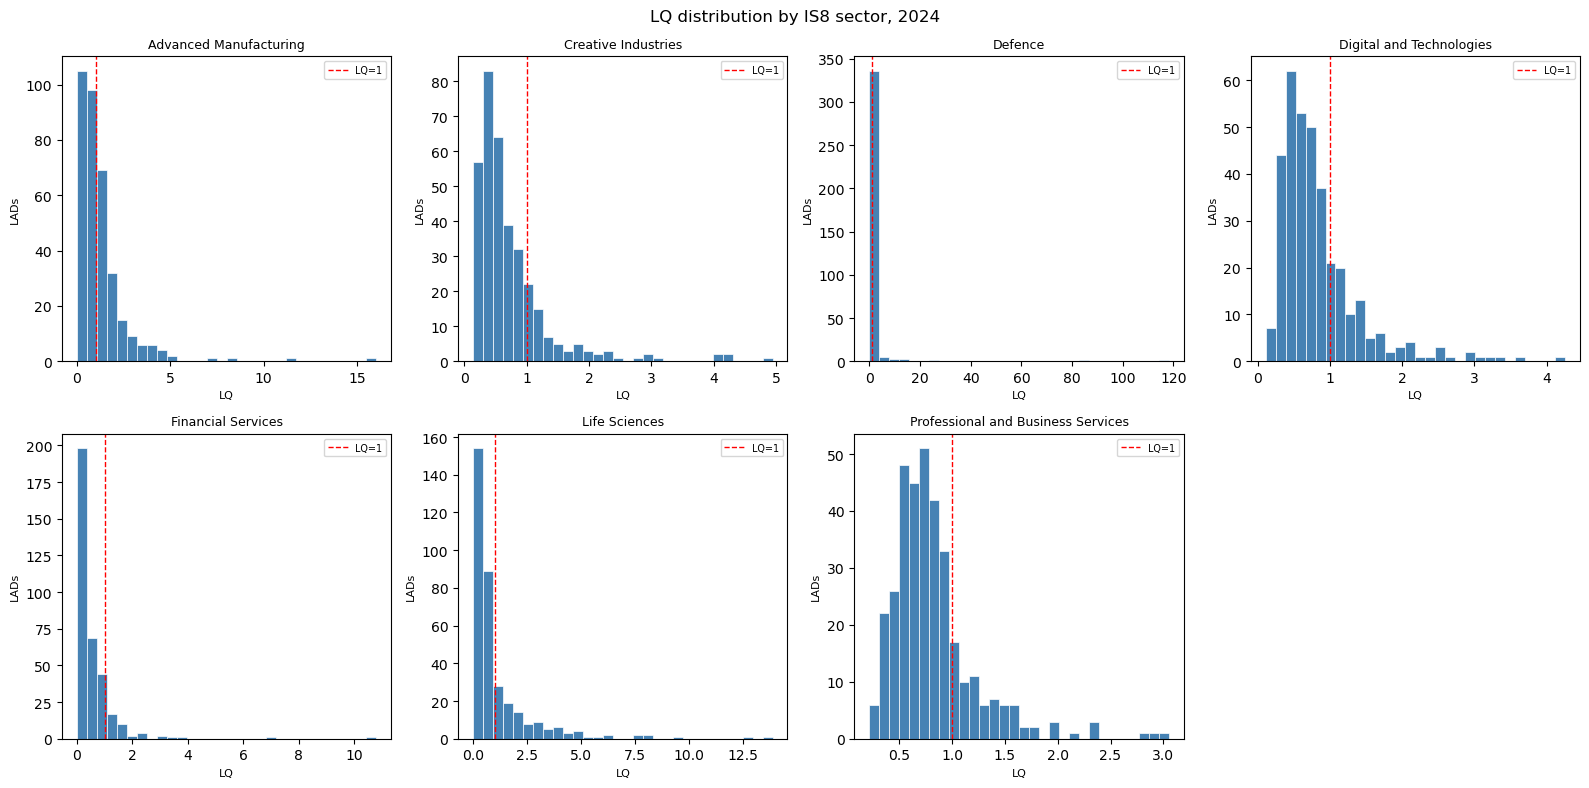

In [5]:
# --- LQ distribution by IS8 sector (most recent year) ---
lq_2024 = panel[panel['YEAR'] == 2024][['GEOGRAPHY_NAME', 'IS8_SECTOR', 'lq_emp']].dropna()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

sectors = sorted(lq_2024['IS8_SECTOR'].unique())

for i, sector in enumerate(sectors):
    data = lq_2024[lq_2024['IS8_SECTOR'] == sector]['lq_emp']
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].axvline(x=1, color='red', linestyle='--', linewidth=1, label='LQ=1')
    axes[i].set_title(sector, fontsize=9)
    axes[i].set_xlabel('LQ', fontsize=8)
    axes[i].set_ylabel('LADs', fontsize=8)
    axes[i].legend(fontsize=7)

# hide the 8th subplot (only 7 sectors)
axes[7].set_visible(False)

plt.suptitle('LQ distribution by IS8 sector, 2024', fontsize=12)
plt.tight_layout()
plt.savefig('../output/charts/lq_distribution_2024.png', dpi=150, bbox_inches='tight')
plt.show()

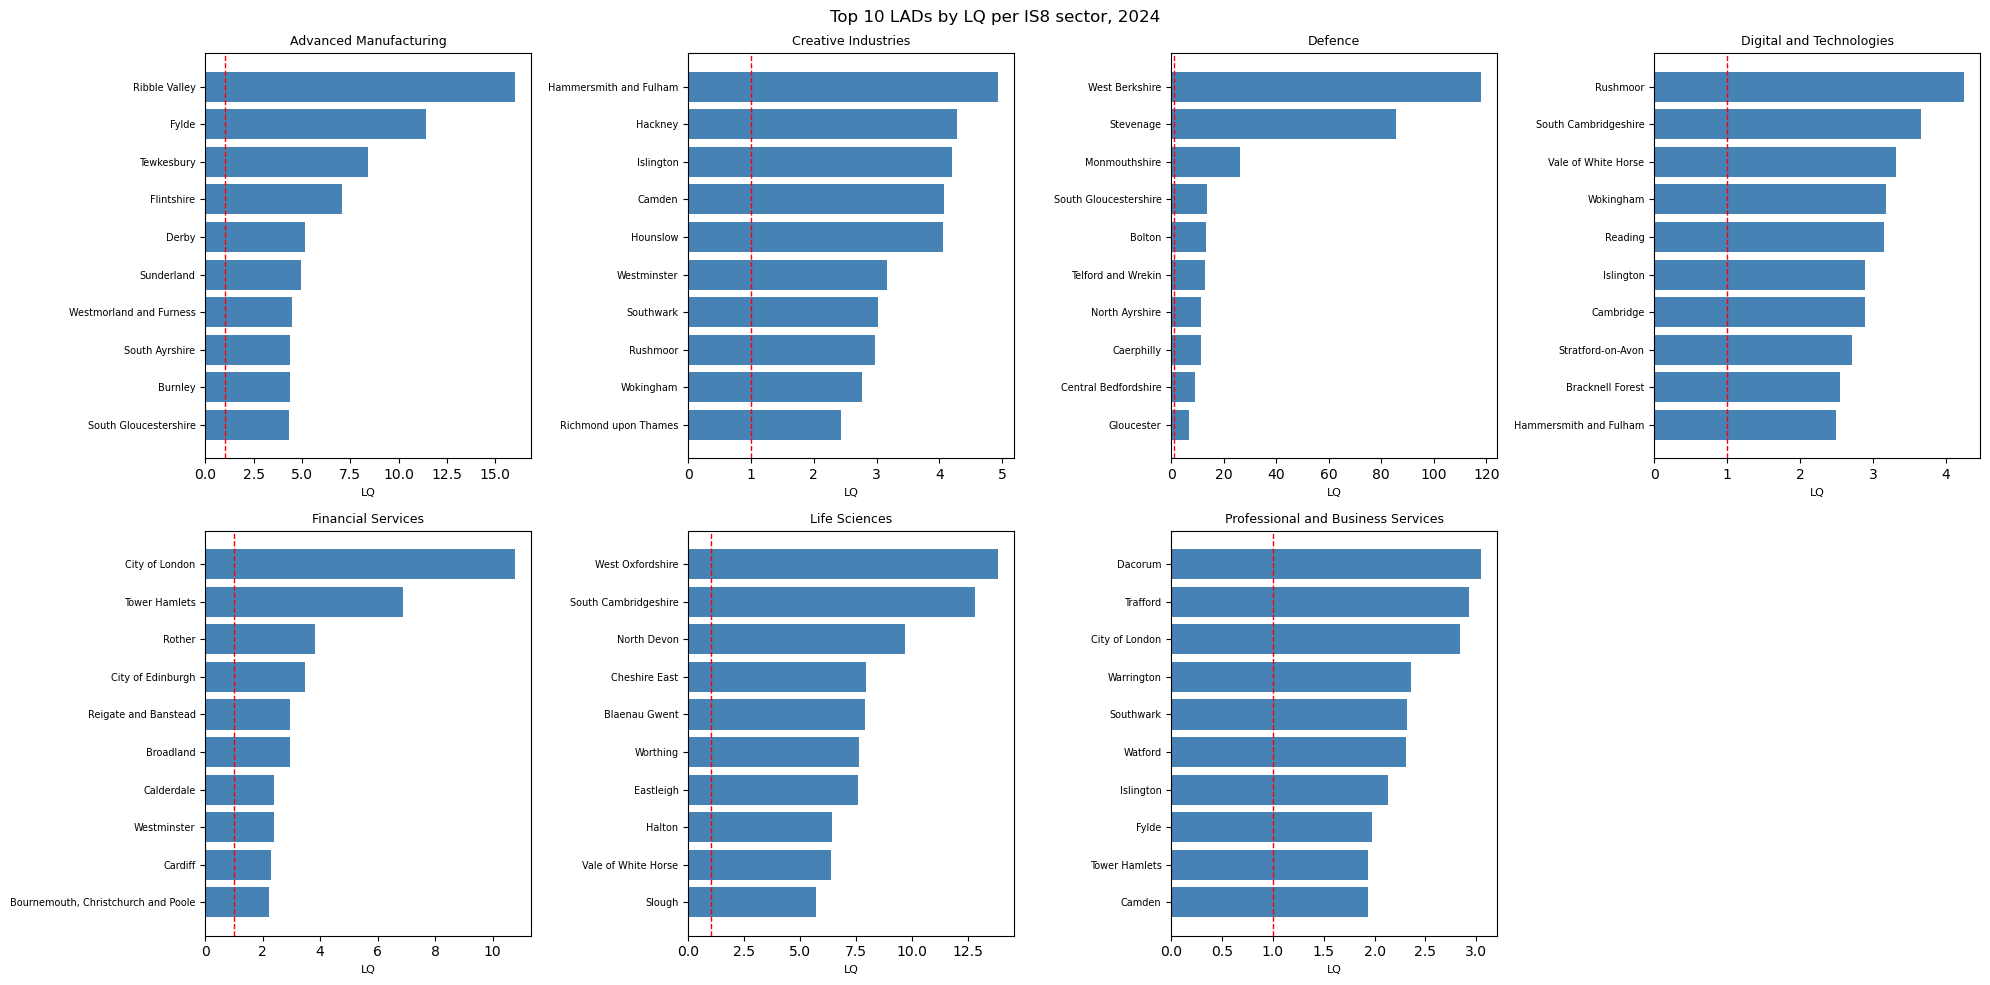

In [6]:
# --- Top 10 LADs by LQ for each IS8 sector (2024) ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, sector in enumerate(sectors):
    data = (
        lq_2024[lq_2024['IS8_SECTOR'] == sector]
        .nlargest(10, 'lq_emp')
        .sort_values('lq_emp', ascending=True)
    )
    axes[i].barh(data['GEOGRAPHY_NAME'], data['lq_emp'], color='steelblue')
    axes[i].axvline(x=1, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(sector, fontsize=9)
    axes[i].set_xlabel('LQ', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)

axes[7].set_visible(False)

plt.suptitle('Top 10 LADs by LQ per IS8 sector, 2024', fontsize=12)
plt.tight_layout()
plt.savefig('../output/charts/top10_lq_by_sector_2024.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
ca_lookup = pd.read_csv("../raw_data/boundaries/MSOA_to_English_combined_authorities.csv")
print(ca_lookup[['CAUTH23CD', 'CAUTH23NM']].drop_duplicates().to_string())

      CAUTH23CD                        CAUTH23NM
0     E47000006                      Tees Valley
50    E47000004            Liverpool City Region
105   E47000009                  West of England
108   E47000008  Cambridgeshire and Peterborough
245   E47000010                       North East
310   E47000011                    North of Tyne
424   E47000001               Greater Manchester
887   E47000002                  South Yorkshire
1144  E47000007                    West Midlands
1360  E47000003                   West Yorkshire


In [8]:
from src.regions import RegionMapper

mapper = RegionMapper(config, panel)
mapper.verify()

South Yorkshire MCA (4 LADs): ['Barnsley', 'Doncaster', 'Rotherham', 'Sheffield']
West Midlands CA (7 LADs): ['Birmingham', 'Coventry', 'Dudley', 'Sandwell', 'Solihull', 'Walsall', 'Wolverhampton']
West Yorkshire CA (5 LADs): ['Bradford', 'Calderdale', 'Kirklees', 'Leeds', 'Wakefield']
Greater Manchester CA (10 LADs): ['Bolton', 'Bury', 'Manchester', 'Oldham', 'Rochdale', 'Salford', 'Stockport', 'Tameside', 'Trafford', 'Wigan']
West of England CA (3 LADs): ['Bath and North East Somerset', 'Bristol, City of', 'South Gloucestershire']
Glasgow City Region (8 LADs): ['East Renfrewshire', 'Inverclyde', 'South Lanarkshire', 'Renfrewshire', 'West Dunbartonshire', 'East Dunbartonshire', 'Glasgow City', 'North Lanarkshire']
Cardiff-Newport (2 LADs): ['Cardiff', 'Newport']


In [9]:
from src.regions import RegionMapper

mapper = RegionMapper(config, panel)
region_map = mapper.get()

# --- Regional LQ profiles (2024) ---
lq_2024 = panel[panel['YEAR'] == 2024][['GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'IS8_SECTOR', 'lq_emp']].dropna()

region_lq = []
for region, codes in region_map.items():
    region_data = lq_2024[lq_2024['GEOGRAPHY_CODE'].isin(codes)]
    avg_lq = region_data.groupby('IS8_SECTOR')['lq_emp'].mean().reset_index()
    avg_lq['region'] = region
    region_lq.append(avg_lq)

region_lq = pd.concat(region_lq, ignore_index=True)

# Pivot for heatmap
lq_pivot = region_lq.pivot(index='region', columns='IS8_SECTOR', values='lq_emp').round(2)
print(lq_pivot.to_string())

IS8_SECTOR             Advanced Manufacturing  Creative Industries  Defence  Digital and Technologies  Financial Services  Life Sciences  Professional and Business Services
region                                                                                                                                                                      
Cardiff-Newport                          0.88                 0.84      0.0                       0.9                1.98           0.76                                0.93
Glasgow City Region                      0.89                 0.49     0.22                      0.64                0.57           0.91                                 0.6
Greater Manchester CA                    0.89                 0.68     1.32                      0.76                0.57           0.67                                1.09
South Yorkshire MCA                       0.7                 0.39      0.0                      0.58                0.56           0.7

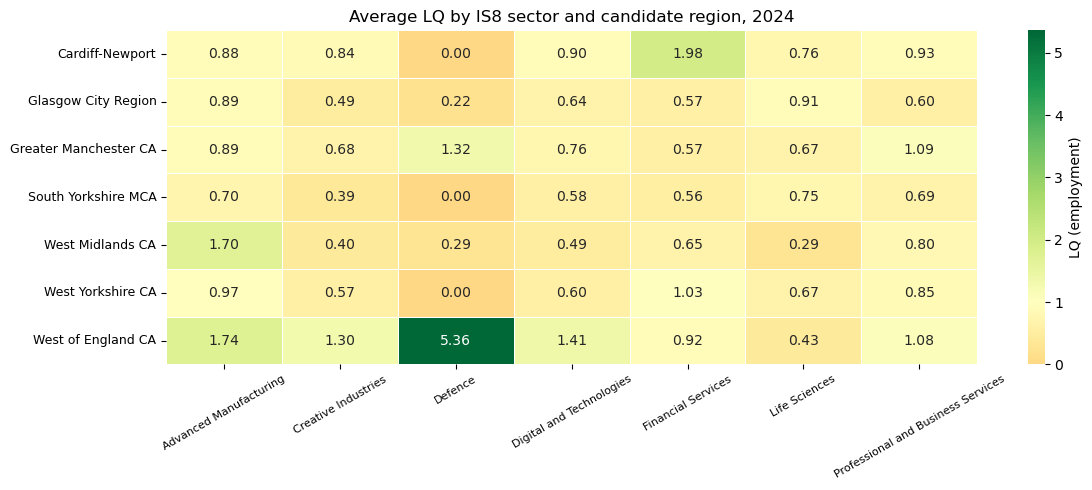

In [10]:
import seaborn as sns

lq_pivot_float = lq_pivot.astype(float)

fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    lq_pivot_float,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'LQ (employment)'}
)

ax.set_title('Average LQ by IS8 sector and candidate region, 2024', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig('../output/charts/regional_lq_heatmap_2024.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# --- Region-level LQ (aggregate LADs first, then compute LQ) ---
year = 2024

# get total employment panel including Total rows
panel_full = pd.read_parquet("../processed_data/analysis_panel.parquet")
panel_2024 = panel_full[panel_full['YEAR'] == year].copy()

region_lq_agg = []

for region, codes in region_map.items():
    # sum employment across LADs in region
    region_emp = (
        panel_2024[panel_2024['GEOGRAPHY_CODE'].isin(codes)]
        .groupby('IS8_SECTOR')['EMPLOYEES']
        .sum()
        .reset_index()
    )
    
    # national employment
    nat_emp = (
        panel_2024
        .groupby('IS8_SECTOR')['EMPLOYEES']
        .sum()
        .reset_index()
        .rename(columns={'EMPLOYEES': 'NAT_EMP'})
    )
    
    # total employment
    region_total = region_emp[region_emp['IS8_SECTOR'] == 'Total']['EMPLOYEES'].values[0]
    nat_total = nat_emp[nat_emp['IS8_SECTOR'] == 'Total']['NAT_EMP'].values[0]
    
    region_emp = region_emp[region_emp['IS8_SECTOR'] != 'Total']
    nat_emp = nat_emp[nat_emp['IS8_SECTOR'] != 'Total']
    
    merged = region_emp.merge(nat_emp, on='IS8_SECTOR')
    merged['lq_region'] = (merged['EMPLOYEES'] / region_total) / (merged['NAT_EMP'] / nat_total)
    merged['region'] = region
    region_lq_agg.append(merged)

region_lq_agg = pd.concat(region_lq_agg, ignore_index=True)
lq_pivot_agg = region_lq_agg.pivot(index='region', columns='IS8_SECTOR', values='lq_region').round(2)
print(lq_pivot_agg.to_string())

IS8_SECTOR             Advanced Manufacturing  Creative Industries  Defence  Digital and Technologies  Financial Services  Life Sciences  Professional and Business Services
region                                                                                                                                                                      
Cardiff-Newport                          0.57                 0.97      0.0                      0.92                2.14           1.04                                0.93
Glasgow City Region                      0.84                 0.68     0.26                       0.8                1.07            0.8                                0.83
Greater Manchester CA                    0.72                 0.89     1.05                      0.92                0.89           0.58                                1.29
South Yorkshire MCA                      0.63                 0.48      0.0                      0.68                0.67           1.0

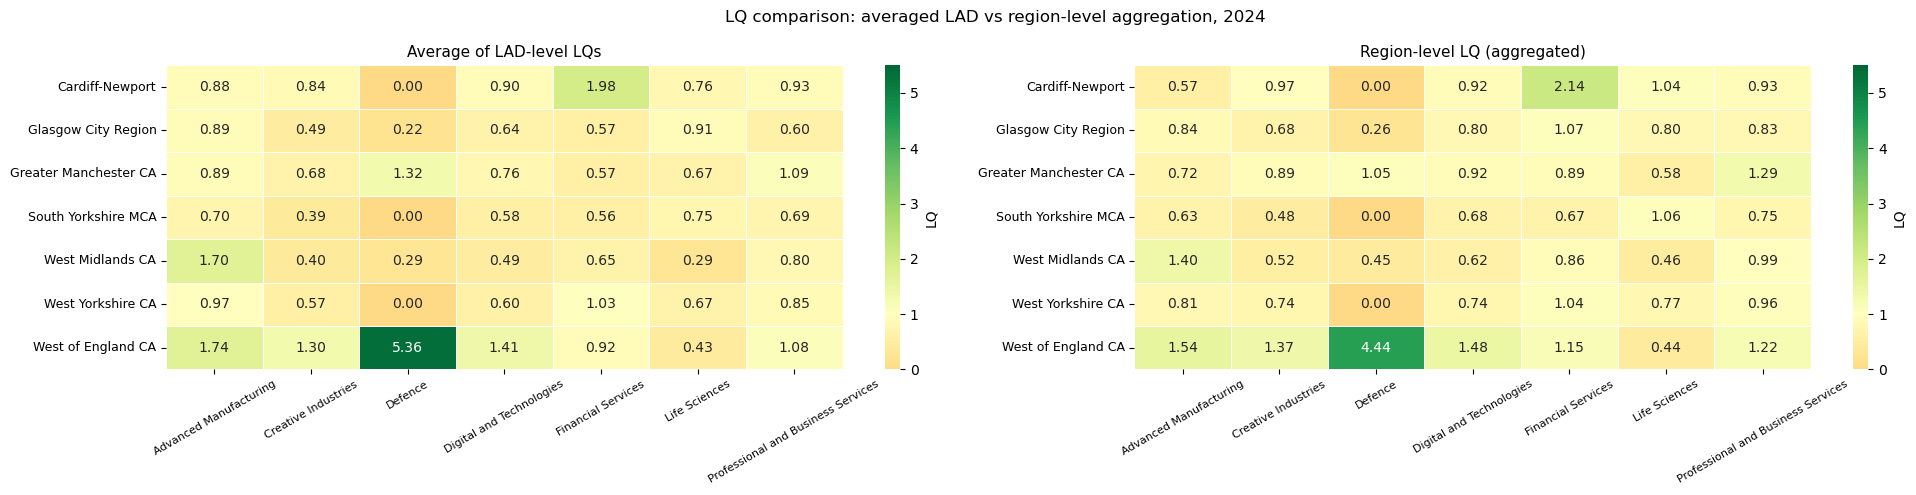

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# averaged LAD LQs
sns.heatmap(
    lq_pivot_float,
    annot=True, fmt='.2f', cmap='RdYlGn', center=1,
    linewidths=0.5, linecolor='white',
    ax=axes[0], cbar_kws={'label': 'LQ'},
    vmin=0, vmax=5.5
)
axes[0].set_title('Average of LAD-level LQs', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# region-level LQs
sns.heatmap(
    lq_pivot_agg.astype(float),
    annot=True, fmt='.2f', cmap='RdYlGn', center=1,
    linewidths=0.5, linecolor='white',
    ax=axes[1], cbar_kws={'label': 'LQ'},
    vmin=0, vmax=5.5
)
axes[1].set_title('Region-level LQ (aggregated)', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle('LQ comparison: averaged LAD vs region-level aggregation, 2024', fontsize=12)
plt.tight_layout()
plt.savefig('../output/charts/regional_lq_comparison_2024.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# --- Regional IS8 employment growth 2015-2024 ---
# growth_emp is identical across all years for a given LAD/sector
# take first non-null value per LAD/sector
growth_data = (
    panel[['GEOGRAPHY_CODE', 'IS8_SECTOR', 'growth_emp']]
    .dropna(subset=['growth_emp'])
    .drop_duplicates(subset=['GEOGRAPHY_CODE', 'IS8_SECTOR'])
)

print(f"Growth data shape: {growth_data.shape}")
print(f"Non-null values: {growth_data['growth_emp'].notna().sum()}")
print(growth_data.head())

Growth data shape: (2153, 3)
Non-null values: 2153
  GEOGRAPHY_CODE                IS8_SECTOR  growth_emp
0      E06000001    Advanced Manufacturing    0.072797
1      E06000001       Creative Industries    0.394495
3      E06000001  Digital and Technologies    -0.29235
4      E06000001        Financial Services   -0.442857
5      E06000001             Life Sciences   -0.833333


In [14]:
# --- Regional IS8 employment growth 2015-2024 ---
growth_cols = ['GEOGRAPHY_CODE', 'IS8_SECTOR', 'growth_emp', 'cagr_emp']
growth_data = panel[panel['YEAR'] == 2024][growth_cols].dropna(subset=['growth_emp'])

region_growth = []
for region, codes in region_map.items():
    region_data = growth_data[growth_data['GEOGRAPHY_CODE'].isin(codes)]
    avg_growth = region_data.groupby('IS8_SECTOR')['growth_emp'].mean().reset_index()
    avg_growth['region'] = region
    region_growth.append(avg_growth)

region_growth = pd.concat(region_growth, ignore_index=True)
growth_pivot = region_growth.pivot(index='region', columns='IS8_SECTOR', values='growth_emp').round(3)

print(growth_pivot.to_string())

IS8_SECTOR             Advanced Manufacturing  Creative Industries  Defence  Digital and Technologies  Financial Services  Life Sciences  Professional and Business Services
region                                                                                                                                                                      
Cardiff-Newport                           0.1                0.885     <NA>                     0.584               0.358          0.595                                 0.3
Glasgow City Region                     0.059                0.199      0.5                    -0.018              -0.352            inf                                0.11
Greater Manchester CA                  -0.109                 0.17      1.5                     0.098              -0.143          0.702                               0.354
South Yorkshire MCA                    -0.234                0.197     <NA>                     0.255              -0.157          1.19

In [15]:
import numpy as np

growth_pivot_clean = growth_pivot.astype(float).replace([np.inf, -np.inf], np.nan)
print(growth_pivot_clean.to_string())

IS8_SECTOR             Advanced Manufacturing  Creative Industries  Defence  Digital and Technologies  Financial Services  Life Sciences  Professional and Business Services
region                                                                                                                                                                      
Cardiff-Newport                         0.100                0.885      NaN                     0.584               0.358          0.595                               0.300
Glasgow City Region                     0.059                0.199     0.50                    -0.018              -0.352            NaN                               0.110
Greater Manchester CA                  -0.109                0.170     1.50                     0.098              -0.143          0.702                               0.354
South Yorkshire MCA                    -0.234                0.197      NaN                     0.255              -0.157          1.19

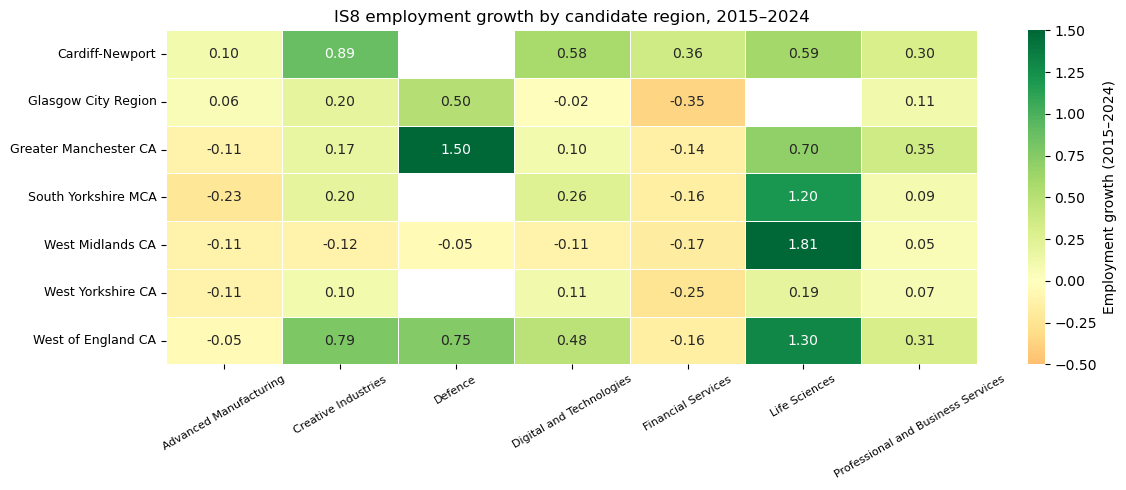

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    growth_pivot_clean,
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Employment growth (2015–2024)'},
    vmin=-0.5, vmax=1.5
)
ax.set_title('IS8 employment growth by candidate region, 2015–2024', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig('../output/charts/regional_growth_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Check business count availability
bus_data = (
    panel[['GEOGRAPHY_CODE', 'IS8_SECTOR', 'YEAR', 'BUSINESSES']]
    .dropna(subset=['BUSINESSES'])
)
print(f"Years with business data: {sorted(bus_data['YEAR'].unique())}")
print(f"Non-null rows: {bus_data.shape[0]:,}")

Years with business data: [np.int16(2016), np.int16(2017), np.int16(2018), np.int16(2019), np.int16(2020), np.int16(2021), np.int16(2022), np.int16(2023), np.int16(2024), np.int16(2025)]
Non-null rows: 24,500


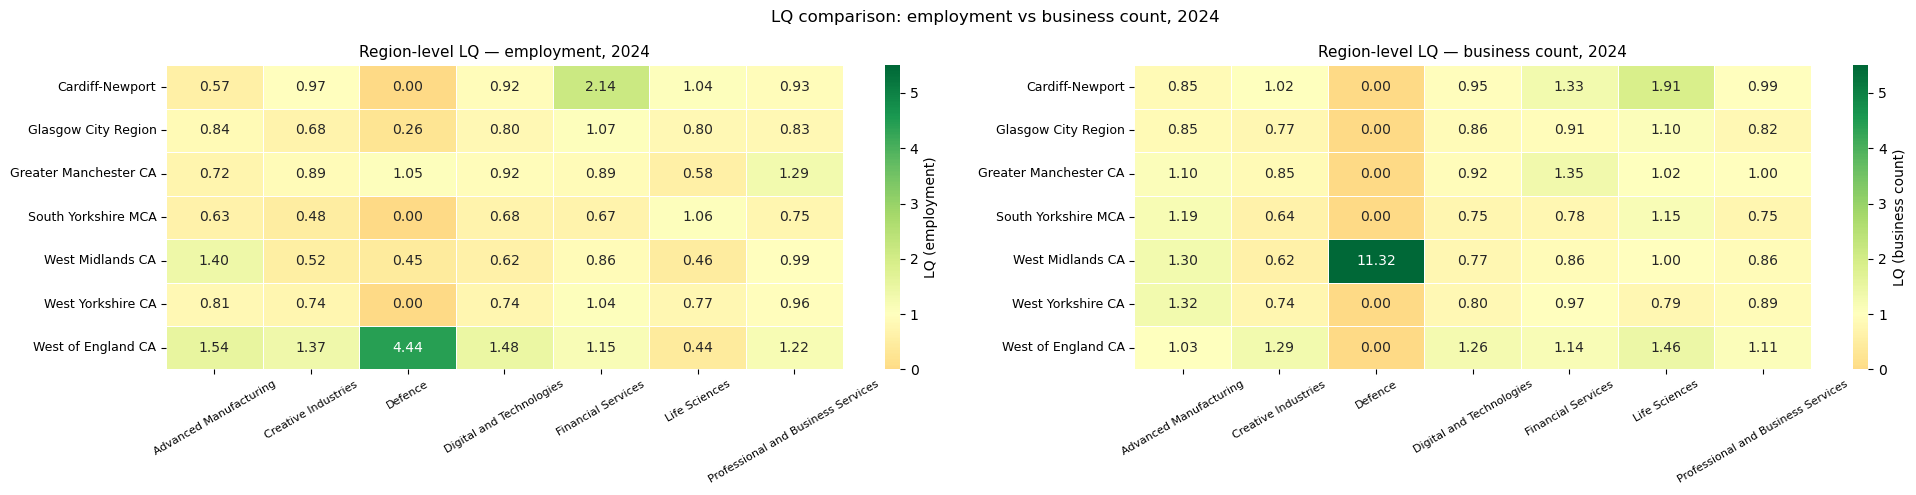

In [18]:
# --- Region-level business count LQ (2024) ---
panel_full_2024 = panel_full[panel_full['YEAR'] == 2024].copy()

region_lq_bus = []

for region, codes in region_map.items():
    region_bus = (
        panel_full_2024[panel_full_2024['GEOGRAPHY_CODE'].isin(codes)]
        .groupby('IS8_SECTOR')['BUSINESSES']
        .sum()
        .reset_index()
    )
    nat_bus = (
        panel_full_2024
        .groupby('IS8_SECTOR')['BUSINESSES']
        .sum()
        .reset_index()
        .rename(columns={'BUSINESSES': 'NAT_BUS'})
    )
    region_total = region_bus[region_bus['IS8_SECTOR'] == 'Total']['BUSINESSES'].values[0]
    nat_total = nat_bus[nat_bus['IS8_SECTOR'] == 'Total']['NAT_BUS'].values[0]

    region_bus = region_bus[region_bus['IS8_SECTOR'] != 'Total']
    nat_bus = nat_bus[nat_bus['IS8_SECTOR'] != 'Total']

    merged = region_bus.merge(nat_bus, on='IS8_SECTOR')
    merged['lq_bus'] = (merged['BUSINESSES'] / region_total) / (merged['NAT_BUS'] / nat_total)
    merged['region'] = region
    region_lq_bus.append(merged)

region_lq_bus = pd.concat(region_lq_bus, ignore_index=True)
lq_bus_pivot = region_lq_bus.pivot(index='region', columns='IS8_SECTOR', values='lq_bus').round(2)

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

sns.heatmap(
    lq_pivot_agg.astype(float),
    annot=True, fmt='.2f', cmap='RdYlGn', center=1,
    linewidths=0.5, linecolor='white',
    ax=axes[0], cbar_kws={'label': 'LQ (employment)'},
    vmin=0, vmax=5.5
)
axes[0].set_title('Region-level LQ — employment, 2024', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

sns.heatmap(
    lq_bus_pivot.astype(float),
    annot=True, fmt='.2f', cmap='RdYlGn', center=1,
    linewidths=0.5, linecolor='white',
    ax=axes[1], cbar_kws={'label': 'LQ (business count)'},
    vmin=0, vmax=5.5
)
axes[1].set_title('Region-level LQ — business count, 2024', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle('LQ comparison: employment vs business count, 2024', fontsize=12)
plt.tight_layout()
plt.savefig('../output/charts/regional_lq_emp_vs_bus_2024.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
panel_ind = pd.read_parquet("../processed_data/indicators_panel.parquet")

print(f"lq_bus present: {'lq_bus' in panel_ind.columns}")
print(f"Non-null lq_bus: {panel_ind['lq_bus'].notna().sum():,}")
print(f"Null lq_bus: {panel_ind['lq_bus'].isna().sum():,}")
print(f"\nSample (Sheffield, Adv Mfg, 2023):")
print(panel_ind[
    (panel_ind['GEOGRAPHY_NAME'] == 'Sheffield') &
    (panel_ind['IS8_SECTOR'] == 'Advanced Manufacturing') &
    (panel_ind['YEAR'] == 2023)
][['lq_emp', 'lq_bus']].values)

lq_bus present: True
Non-null lq_bus: 24,500
Null lq_bus: 2,450

Sample (Sheffield, Adv Mfg, 2023):
[[0.49832894523588117 1.2400116769511078]]


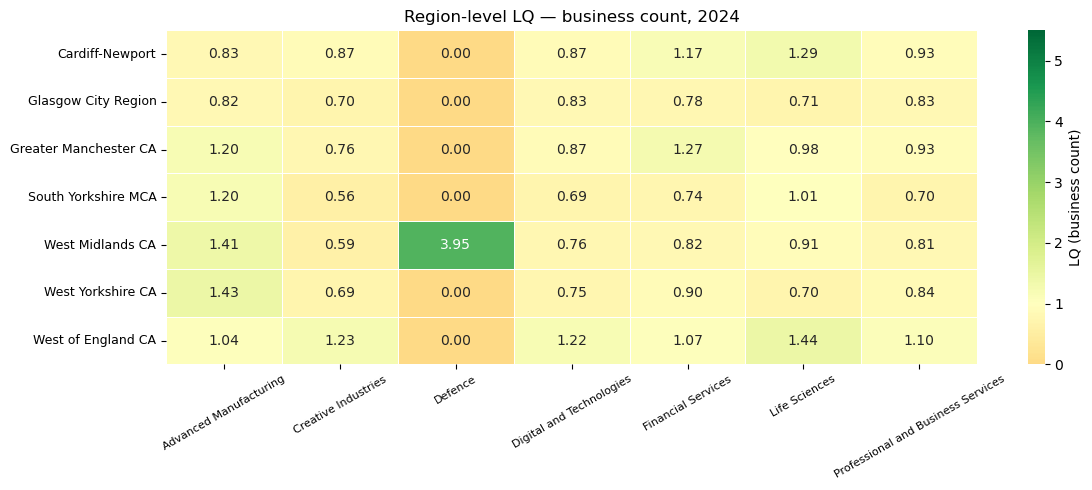

In [20]:
# --- Region-level LQ bus (from indicators panel) ---
lq_bus_2024 = panel_ind[panel_ind['YEAR'] == 2024][['GEOGRAPHY_CODE', 'IS8_SECTOR', 'lq_bus']].dropna()

region_lq_bus2 = []
for region, codes in region_map.items():
    region_data = lq_bus_2024[lq_bus_2024['GEOGRAPHY_CODE'].isin(codes)]
    avg_lq = region_data.groupby('IS8_SECTOR')['lq_bus'].mean().reset_index()
    avg_lq['region'] = region
    region_lq_bus2.append(avg_lq)

region_lq_bus2 = pd.concat(region_lq_bus2, ignore_index=True)
lq_bus_pivot2 = region_lq_bus2.pivot(index='region', columns='IS8_SECTOR', values='lq_bus').round(2)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    lq_bus_pivot2.astype(float),
    annot=True, fmt='.2f', cmap='RdYlGn', center=1,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'LQ (business count)'},
    vmin=0, vmax=5.5
)
ax.set_title('Region-level LQ — business count, 2024', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig('../output/charts/regional_lq_bus_2024.png', dpi=150, bbox_inches='tight')
plt.show()

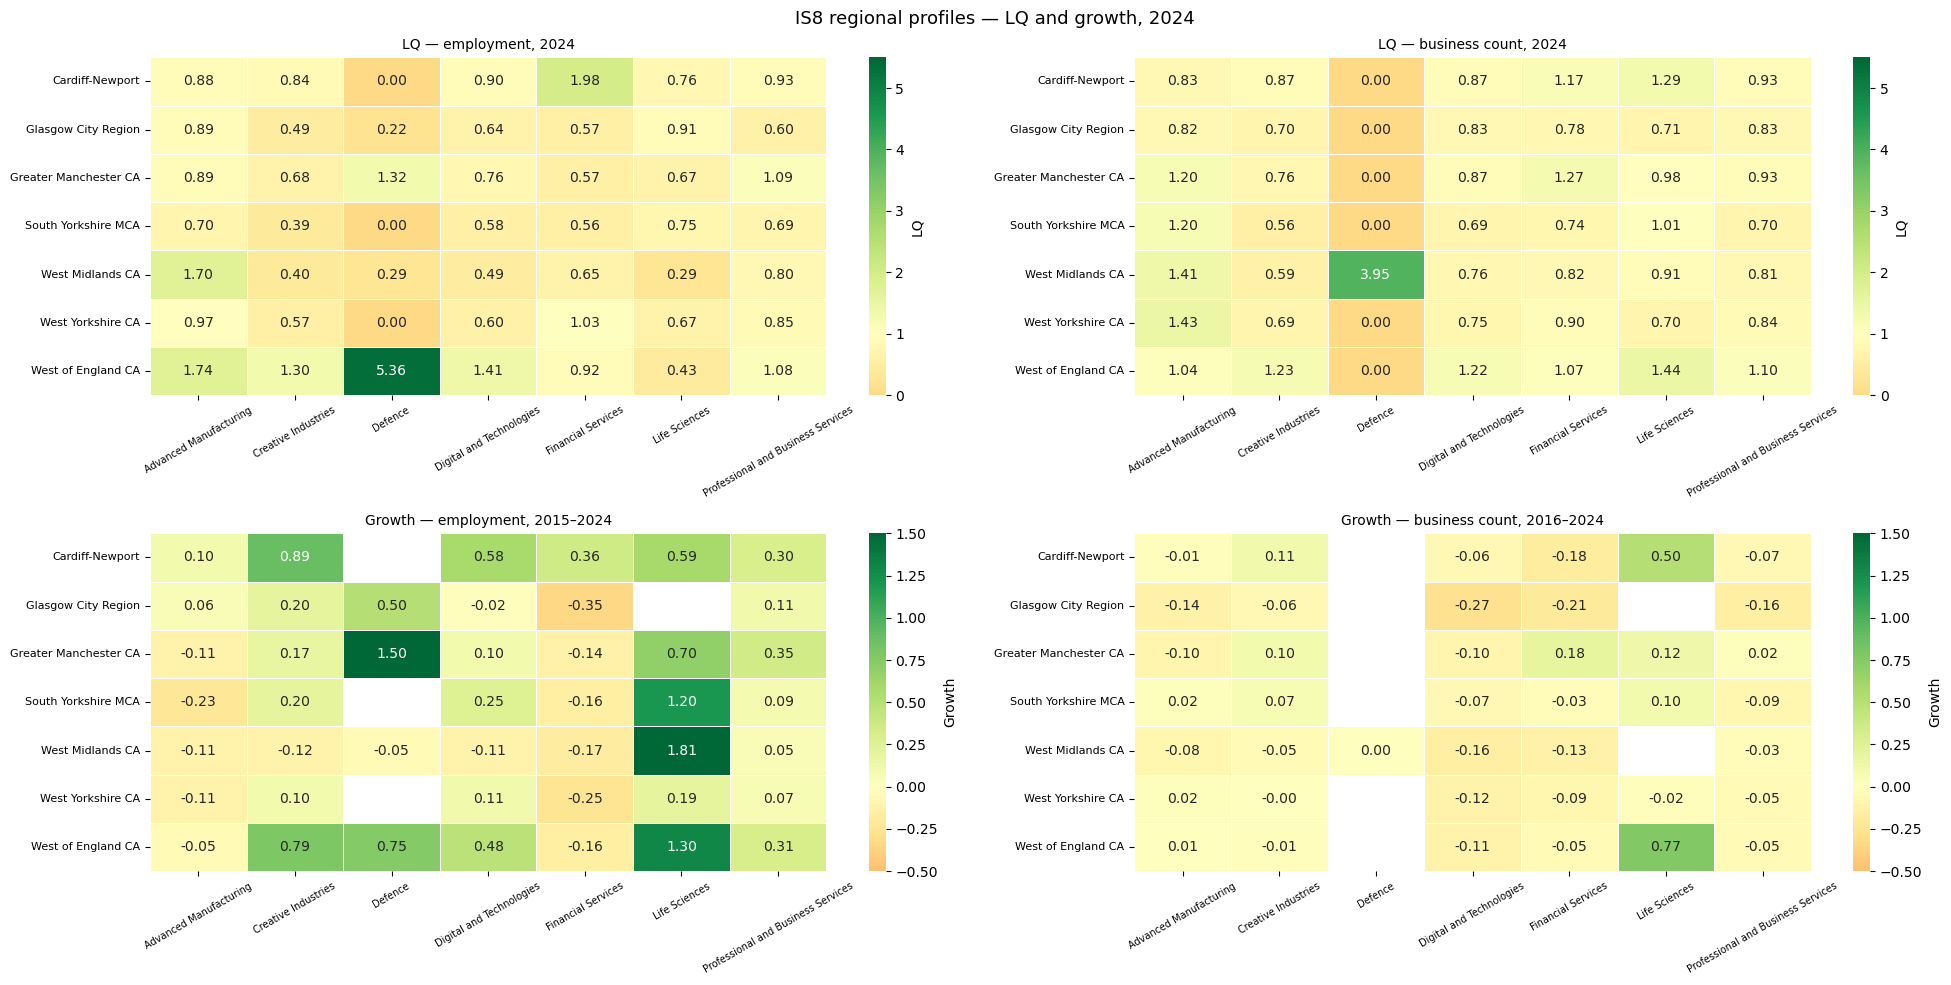

In [21]:
# --- Combined 4-variable heatmap ---

# growth_bus from indicators panel
growth_bus_data = (
    panel_ind[['GEOGRAPHY_CODE', 'IS8_SECTOR', 'growth_bus']]
    .dropna(subset=['growth_bus'])
    .drop_duplicates(subset=['GEOGRAPHY_CODE', 'IS8_SECTOR'])
)

# build all 4 pivots at region level
def region_pivot(data, value_col):
    rows = []
    for region, codes in region_map.items():
        region_data = data[data['GEOGRAPHY_CODE'].isin(codes)]
        avg = region_data.groupby('IS8_SECTOR')[value_col].mean().reset_index()
        avg['region'] = region
        rows.append(avg)
    df = pd.concat(rows, ignore_index=True)
    return df.pivot(index='region', columns='IS8_SECTOR', values=value_col).round(2)

lq_emp_pivot  = region_pivot(panel_ind[panel_ind['YEAR']==2024][['GEOGRAPHY_CODE','IS8_SECTOR','lq_emp']].dropna(), 'lq_emp')
lq_bus_pivot3 = region_pivot(panel_ind[panel_ind['YEAR']==2024][['GEOGRAPHY_CODE','IS8_SECTOR','lq_bus']].dropna(), 'lq_bus')
growth_emp_pivot = region_pivot(growth_data, 'growth_emp')
growth_bus_pivot = region_pivot(growth_bus_data, 'growth_bus')

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

heatmap_configs = [
    (lq_emp_pivot,   'LQ — employment, 2024',          1, 0, 5.5, 'LQ'),
    (lq_bus_pivot3,  'LQ — business count, 2024',       1, 0, 5.5, 'LQ'),
    (growth_emp_pivot, 'Growth — employment, 2015–2024', 0, -0.5, 1.5, 'Growth'),
    (growth_bus_pivot, 'Growth — business count, 2016–2024', 0, -0.5, 1.5, 'Growth'),
]

for ax, (pivot, title, center, vmin, vmax, label) in zip(axes.flatten(), heatmap_configs):
    sns.heatmap(
        pivot.astype(float).replace([np.inf, -np.inf], np.nan),
        annot=True, fmt='.2f', cmap='RdYlGn', center=center,
        linewidths=0.5, linecolor='white',
        ax=ax, cbar_kws={'label': label},
        vmin=vmin, vmax=vmax
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('IS8 regional profiles — LQ and growth, 2024', fontsize=13)
plt.tight_layout()
plt.savefig('../output/charts/regional_full_profile.png', dpi=150, bbox_inches='tight')
plt.show()

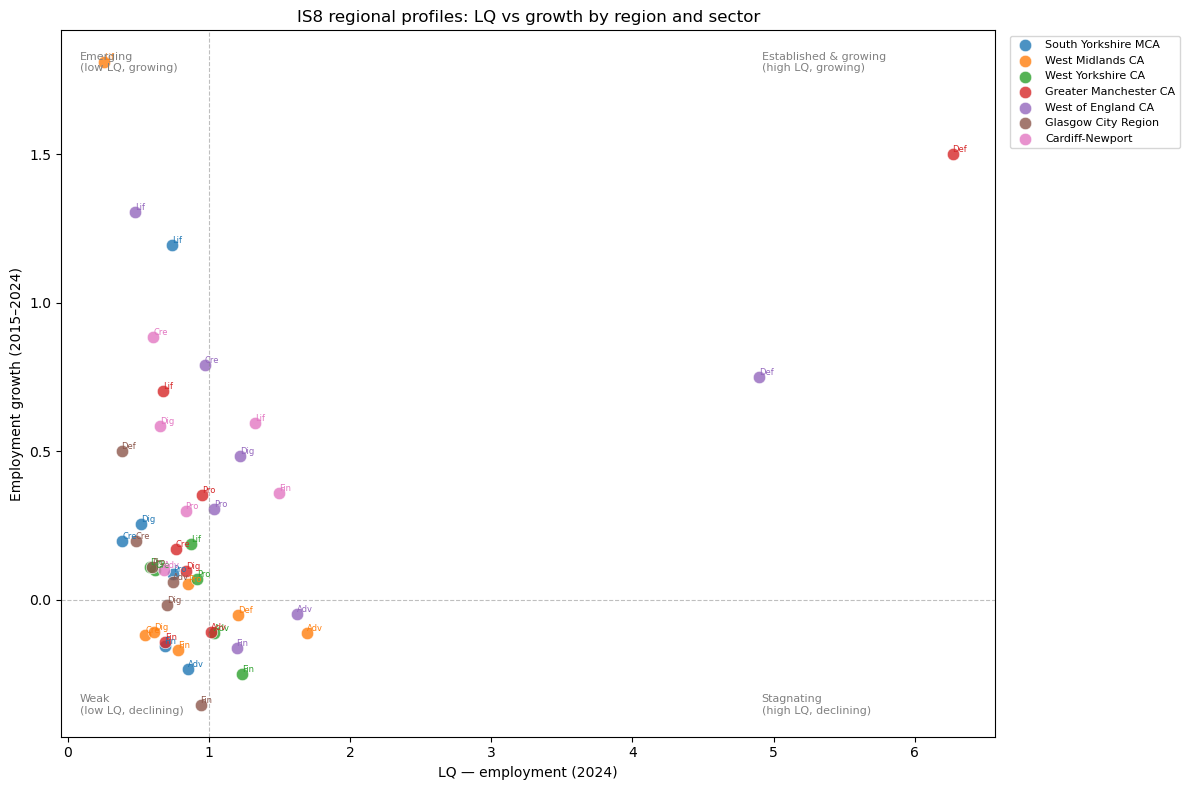

In [22]:
# --- 2D scatter: LQ vs growth by region and sector ---
# Use employment LQ and employment growth as the two axes

# get growth (deduplicated)
growth_dedup = (
    panel_ind[['GEOGRAPHY_CODE', 'IS8_SECTOR', 'growth_emp', 'lq_emp']]
    .dropna(subset=['growth_emp', 'lq_emp'])
    .drop_duplicates(subset=['GEOGRAPHY_CODE', 'IS8_SECTOR'])
)

# aggregate to region level per sector
scatter_data = []
for region, codes in region_map.items():
    region_data = growth_dedup[growth_dedup['GEOGRAPHY_CODE'].isin(codes)]
    avg = region_data.groupby('IS8_SECTOR')[['lq_emp', 'growth_emp']].mean().reset_index()
    avg['region'] = region
    scatter_data.append(avg)

scatter_df = pd.concat(scatter_data, ignore_index=True)

# plot
regions = scatter_df['region'].unique()
colors = plt.cm.tab10.colors
region_colors = {r: colors[i] for i, r in enumerate(regions)}

fig, ax = plt.subplots(figsize=(12, 8))

for region in regions:
    data = scatter_df[scatter_df['region'] == region]
    ax.scatter(data['lq_emp'], data['growth_emp'],
               color=region_colors[region], label=region,
               s=80, alpha=0.8, edgecolors='white', linewidth=0.5)
    # label each dot with sector initial
    for _, row in data.iterrows():
        ax.annotate(row['IS8_SECTOR'][:3],
                    (row['lq_emp'], row['growth_emp']),
                    fontsize=6, ha='left', va='bottom',
                    color=region_colors[region])

# quadrant lines
ax.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# quadrant labels
ax.text(0.02, 0.97, 'Emerging\n(low LQ, growing)', transform=ax.transAxes,
        fontsize=8, va='top', color='gray')
ax.text(0.75, 0.97, 'Established & growing\n(high LQ, growing)', transform=ax.transAxes,
        fontsize=8, va='top', color='gray')
ax.text(0.02, 0.03, 'Weak\n(low LQ, declining)', transform=ax.transAxes,
        fontsize=8, va='bottom', color='gray')
ax.text(0.75, 0.03, 'Stagnating\n(high LQ, declining)', transform=ax.transAxes,
        fontsize=8, va='bottom', color='gray')

ax.set_xlabel('LQ — employment (2024)', fontsize=10)
ax.set_ylabel('Employment growth (2015–2024)', fontsize=10)
ax.set_title('IS8 regional profiles: LQ vs growth by region and sector', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../output/charts/regional_scatter_lq_growth.png', dpi=150, bbox_inches='tight')
plt.show()

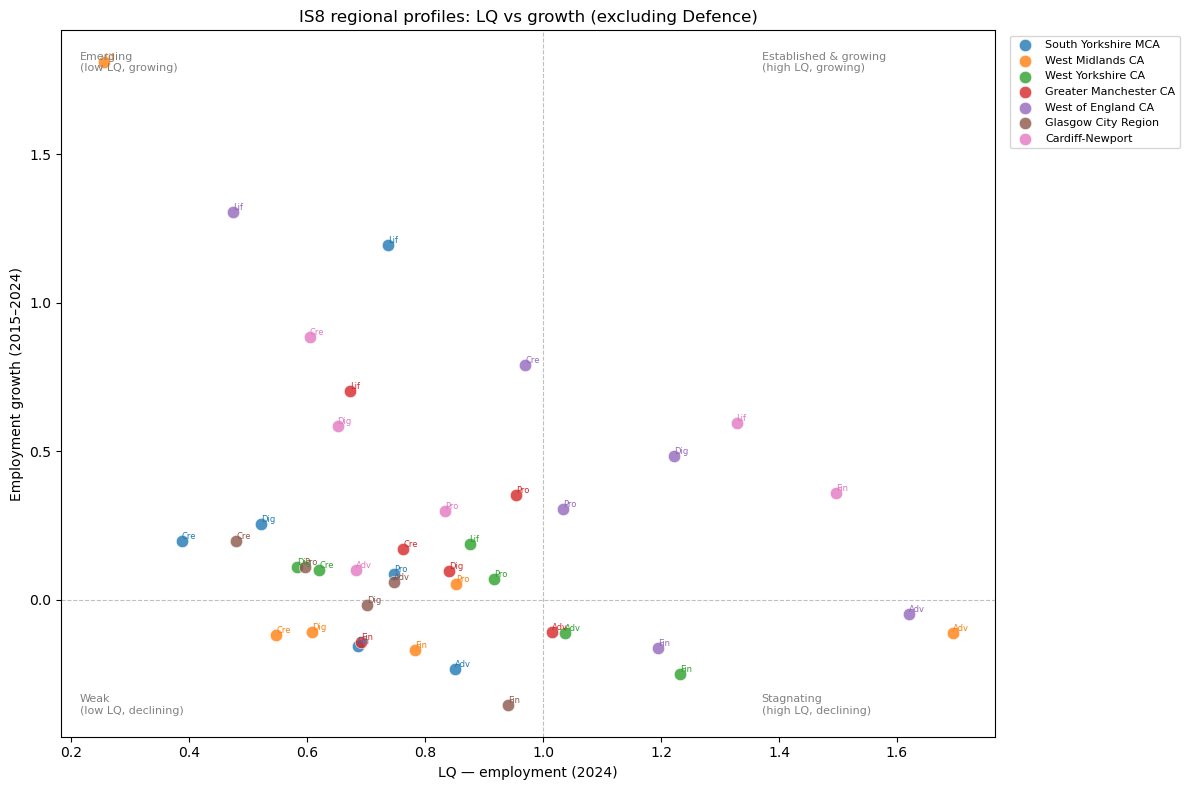

In [23]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter_no_def = scatter_df[scatter_df['IS8_SECTOR'] != 'Defence']

for region in regions:
    data = scatter_no_def[scatter_no_def['region'] == region]
    ax.scatter(data['lq_emp'], data['growth_emp'],
               color=region_colors[region], label=region,
               s=80, alpha=0.8, edgecolors='white', linewidth=0.5)
    for _, row in data.iterrows():
        ax.annotate(row['IS8_SECTOR'][:3],
                    (row['lq_emp'], row['growth_emp']),
                    fontsize=6, ha='left', va='bottom',
                    color=region_colors[region])

ax.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

ax.text(0.02, 0.97, 'Emerging\n(low LQ, growing)', transform=ax.transAxes,
        fontsize=8, va='top', color='gray')
ax.text(0.75, 0.97, 'Established & growing\n(high LQ, growing)', transform=ax.transAxes,
        fontsize=8, va='top', color='gray')
ax.text(0.02, 0.03, 'Weak\n(low LQ, declining)', transform=ax.transAxes,
        fontsize=8, va='bottom', color='gray')
ax.text(0.75, 0.03, 'Stagnating\n(high LQ, declining)', transform=ax.transAxes,
        fontsize=8, va='bottom', color='gray')

ax.set_xlabel('LQ — employment (2024)', fontsize=10)
ax.set_ylabel('Employment growth (2015–2024)', fontsize=10)
ax.set_title('IS8 regional profiles: LQ vs growth (excluding Defence)', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../output/charts/regional_scatter_lq_growth_no_defence.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
for region in ['West of England CA', 'Cardiff-Newport', 'Greater Manchester CA']:
    codes = region_map[region]
    names = panel[panel['GEOGRAPHY_CODE'].isin(codes)]['GEOGRAPHY_NAME'].unique().tolist()
    print(f"{region} ({len(codes)} LADs): {names}")

West of England CA (3 LADs): ['Bath and North East Somerset', 'Bristol, City of', 'South Gloucestershire']
Cardiff-Newport (2 LADs): ['Cardiff', 'Newport']
Greater Manchester CA (10 LADs): ['Bolton', 'Bury', 'Manchester', 'Oldham', 'Rochdale', 'Salford', 'Stockport', 'Tameside', 'Trafford', 'Wigan']
